<a href="https://colab.research.google.com/github/Mansi-3s/Creditt_wise_loan/blob/main/ANN_for_regression_classification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

###ANN (Artificial Neural Network)

*   Regression
*   Classification

ANN for regression using PYTORCH. steps are:-


1.   Load the dataset.

2.   convert the data into pytorch tensors.

3.   We create tensor dataset and Data loader.

4.   Define ANN model.

5.   Train the model. -> Save the model

6.   Evaluate




In [ ]:
import pandas as pd
df = pd.read_csv("/content/powerplant_data.csv")
df.head()

,AT,V,AP,RH,PE
0,8.34,40.77,1010.84,90.01,480.48
1,23.64,58.49,1011.40,74.20,445.75
2,29.74,56.90,1007.15,41.91,438.76
3,19.07,49.69,1007.22,76.79,453.09
4,11.80,40.66,1017.13,97.20,464.43


AT= temperature


V = vaccum


AP = pressure


RH = humidity


PE = produce energy / produce output


In [ ]:
df.isnull().sum()

,0
AT,0
V,0
AP,0
RH,0
PE,0


In [ ]:
X = df.drop(['PE'], axis = 1)
y = df['PE']

In [ ]:
y.head()

,PE
0,480.48
1,445.75
2,438.76
3,453.09
4,464.43


In [ ]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 42)

In [ ]:
df.shape

(9568, 5)

In [ ]:
from sklearn.preprocessing import StandardScaler
sc = StandardScaler()
X_train_scaled = sc.fit_transform(X_train)
X_test_scaled = sc.transform(X_test)

In [ ]:
y_train.shape  #data in 1D eg[1,2,3,4,5,6....]

(7654,)

In [ ]:
import torch
import torch.nn as nn                        # they all are stored in RAM

X_train_tensor = torch.tensor(X_train_scaled, dtype = torch.float32)
X_test_tensor = torch.tensor(X_test_scaled, dtype = torch.float32)
#we do standarScaler for X_train, X_test not for y, so y still a numpy array

y_test_tensor = torch.tensor(y_test.values, dtype = torch.float32).view(-1, 1)
y_train_tensor = torch.tensor(y_train.values, dtype = torch.float32).view(-1, 1) #y_train panda series
#.view(row, column) convert dimension eg:
# [1,2,3]  to
 #[[1],
#[2],
#[3]] used to build right tensor

In [ ]:
type(X_train_scaled) # no need .value

numpy.ndarray

In [ ]:
y_train_tensor.shape

torch.Size([7654, 1])

In [ ]:
type(y_train)
#y = label
# y_train is panda series use .value, to access values directly

pandas.core.series.Series

In [ ]:
#Create Tensor Dataset and Data Loader.
from torch.utils.data import TensorDataset, DataLoader
train_dataset = TensorDataset(X_train_tensor, y_train_tensor) #(input_feature, output_features)
test_dataset = TensorDataset(X_test_tensor, y_test_tensor)

In [ ]:
train_loader = DataLoader(train_dataset, batch_size = 32, shuffle = True)
test_loader = DataLoader(test_dataset, batch_size= 32)

#Deep Learning
Define ANN model

In [ ]:
class ANN(nn.Module):
  def __init__(self):   #constructor -which is to call superconstructor(we call nn.Modeule class constructor, to intialise neural ntwk model.)
    super(ANN, self).__init__()
    self.model = nn.Sequential(
        #1st hidden layer
        nn.Linear(X_train.shape[1], 6),#(input_festures, output_features) we dont need to define input layer
        nn.ReLU(),

        #2 hidden layer
        nn.Linear(6, 6),
        nn.ReLU(),

        #Output layer
        nn.Linear(6, 1)
    )

  # define forward_propagation
  def forward(self, X):
    return self.model(X)

In [ ]:
#loss function in-built
import torch.optim as optim
model = ANN()

#LOSS, OPTIMIZER

criterion = nn.MSELoss()  #we figreout our gradient descent curve, how it look like. if MSE decreasing then it show loss function minimizes
optimizer = optim.Adam(model.parameters(), lr = 0.001) # parameters like weight, bias

#Train th ANN

In [ ]:
#train ANN
train_loss = []
val_loss = []

best_val_loss = float('inf')
num_epochs = 100

for epoch in range(num_epochs):
  model.train()  #on training mode we adjust weights,  by backpropagation. this is learning phase
  running_loss = 0.0 ## total traning loss for 1 epoch

  for xb, yb in train_loader:

     # (xb) X_train_batch=features of 1 batch
     # (yb) y_train_batch = labels of 1 batch

     optimizer.zero_grad() #zero the parameter gradients

     outputs = model(xb) #forward prop...predicted output for this batch
     loss = criterion(outputs, yb) #compute loss
     loss.backward() #back prop... compute gradients
     optimizer.step() # update parameters

     running_loss += loss.item() # loss is a tensor so we convert it into >> py float
  #running loss is  sum of loss for all the batches
  # loss =  loss for 1 batch
  #avg loss per batch for 1 epoch = running loss / total no. of batches... we stored for each epoch
  # train loss = avg loss per batch


  epoch_train_loss = running_loss / len(train_loader)
  train_loss.append(epoch_train_loss)



  #validation  ##during validation no backward propa.. because validation is  on test data
  model.eval()
  running_val_loss = 0.0

  with torch.no_grad(): #no need to compute gradients , we save memory, and speed up below computations
    for xb, yb in test_loader:
      outputs = model(xb)
      loss = criterion(outputs, yb)
      running_val_loss += loss.item()

  epoch_val_loss = running_val_loss / len(test_loader)
  val_loss.append(epoch_val_loss)


  print(f"epoch {epoch+1}/{num_epochs} ==> train loss = {epoch_train_loss:.4f} & val loss =  {epoch_val_loss:.4f} ")

  if epoch_val_loss < best_val_loss:
    best_val_loss = epoch_val_loss
    torch.save(model.state_dict(), "best_model.pt")  #model store/save = .pt or .pth

epoch 1/100 ==> train loss = 205226.8052 & val loss =  202092.6839 
epoch 2/100 ==> train loss = 191318.6956 & val loss =  174171.1651 
epoch 3/100 ==> train loss = 146210.2200 & val loss =  114004.6122 
epoch 4/100 ==> train loss = 83451.3175 & val loss =  56360.5115 
epoch 5/100 ==> train loss = 40299.5799 & val loss =  27301.4926 
epoch 6/100 ==> train loss = 21125.1340 & val loss =  15623.3614 
epoch 7/100 ==> train loss = 13419.1498 & val loss =  10894.7965 
epoch 8/100 ==> train loss = 9735.1812 & val loss =  8008.3205 
epoch 9/100 ==> train loss = 7113.4595 & val loss =  5762.6805 
epoch 10/100 ==> train loss = 5013.5766 & val loss =  3964.2341 
epoch 11/100 ==> train loss = 3421.1972 & val loss =  2667.5799 
epoch 12/100 ==> train loss = 2315.9559 & val loss =  1838.2807 
epoch 13/100 ==> train loss = 1660.3950 & val loss =  1344.8106 
epoch 14/100 ==> train loss = 1238.6304 & val loss =  1017.1682 
epoch 15/100 ==> train loss = 950.1556 & val loss =  791.9434 
epoch 16/100 ==>

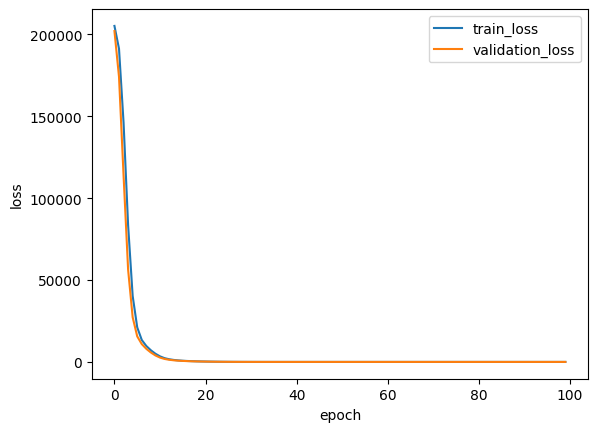

In [ ]:
import matplotlib.pyplot as plt

loss_df = pd.DataFrame({
    "trainin_loss": train_loss,
    "validation_loss": val_loss
})


plt.plot(loss_df["trainin_loss"], label = "train_loss")
plt.plot(loss_df["validation_loss"], label = "validation_loss")
plt.xlabel("epoch")
plt.ylabel("loss")
plt.legend()
plt.show()

### Loading Best Model

In [ ]:
model.load_state_dict(torch.load("best_model.pt"))

<All keys matched successfully>

##Evaluation

In [ ]:
model.eval()
with torch.no_grad():
  train_pred = model(X_train_tensor)
  test_pred = model(X_test_tensor)

  train_mse_loss = criterion(train_pred, y_train_tensor)
  test_mse_loss = criterion(test_pred, y_test_tensor)

In [ ]:
print("Trainin MSE ", train_mse_loss.item())
print("Testing MSE ", test_mse_loss)

Trainin MSE  20.59992790222168
Testing MSE  tensor(18.7874)


In [ ]:
from sklearn.metrics import r2_score
print("Training R2 Score ", r2_score(y_test, test_pred))

Training R2 Score  0.9343427983140099


In [ ]:
#compare actual vs predictes
predicted_df = pd.DataFrame(test_pred.numpy(), columns=["Predicted Values"])
actual_df = pd.DataFrame(y_test.values, columns=["Actual Values"])

pd.concat([actual_df, predicted_df], axis = 1)

,Actual Values,Predicted Values
0,433.27,434.993225
1,438.16,436.494385
2,458.42,461.455383
3,480.82,476.233856
4,441.41,435.477600
...,...,...
1909,456.70,450.904785
1910,438.04,431.308472
1911,467.80,467.242401
1912,437.14,430.745728


### ANN for Classification
####Multi-class Classification problem of ANN

In [ ]:
import pandas as pd

df = pd.read_csv("/content/DateFruit_Dataset.csv")

In [ ]:
df.head() #34 features and 1 category

,AREA,PERIMETER,MAJOR_AXIS,MINOR_AXIS,ECCENTRICITY,EQDIASQ,SOLIDITY,CONVEX_AREA,EXTENT,ASPECT_RATIO,...,KurtosisRR,KurtosisRG,KurtosisRB,EntropyRR,EntropyRG,EntropyRB,ALLdaub4RR,ALLdaub4RG,ALLdaub4RB,Class
0,422163,2378.908,837.8484,645.6693,0.6373,733.1539,0.9947,424428,0.7831,1.2976,...,3.2370,2.9574,4.2287,-59191263232,-50714214400,-39922372608,58.7255,54.9554,47.8400,BERHI
1,338136,2085.144,723.8198,595.2073,0.5690,656.1464,0.9974,339014,0.7795,1.2161,...,2.6228,2.6350,3.1704,-34233065472,-37462601728,-31477794816,50.0259,52.8168,47.8315,BERHI
2,526843,2647.394,940.7379,715.3638,0.6494,819.0222,0.9962,528876,0.7657,1.3150,...,3.7516,3.8611,4.7192,-93948354560,-74738221056,-60311207936,65.4772,59.2860,51.9378,BERHI
3,416063,2351.210,827.9804,645.2988,0.6266,727.8378,0.9948,418255,0.7759,1.2831,...,5.0401,8.6136,8.2618,-32074307584,-32060925952,-29575010304,43.3900,44.1259,41.1882,BERHI
4,347562,2160.354,763.9877,582.8359,0.6465,665.2291,0.9908,350797,0.7569,1.3108,...,2.7016,2.9761,4.4146,-39980974080,-35980042240,-25593278464,52.7743,50.9080,42.6666,BERHI


In [ ]:
#missinng value
df.isnull().sum()

,0
AREA,0
PERIMETER,0
MAJOR_AXIS,0
MINOR_AXIS,0
ECCENTRICITY,0
EQDIASQ,0
SOLIDITY,0
CONVEX_AREA,0
EXTENT,0
ASPECT_RATIO,0


In [ ]:
df.shape

(898, 35)

In [ ]:
X = df.drop("Class", axis = 1)
y = df["Class"]

In [ ]:
df["Class"].unique()

array(['BERHI', 'DEGLET', 'DOKOL', 'IRAQI', 'ROTANA', 'SAFAVI', 'SOGAY'],
      dtype=object)

In [ ]:
# ie. output layer has 7 neurons , in multiclass no of class == no. of output
#ANN architecture : 1-2 hidden layers, in hidden layer we start with do 32 neuron, 64 neuron....
#if underfitting == we increase no. of neurons
#we use 64 neuron

In [ ]:
from sklearn.preprocessing import StandardScaler, LabelEncoder
sc = StandardScaler()
le = LabelEncoder()
y = le.fit_transform(y)

In [ ]:
y

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,

In [ ]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 42)

In [ ]:
X_test

,AREA,PERIMETER,MAJOR_AXIS,MINOR_AXIS,ECCENTRICITY,EQDIASQ,SOLIDITY,CONVEX_AREA,EXTENT,ASPECT_RATIO,...,SkewRB,KurtosisRR,KurtosisRG,KurtosisRB,EntropyRR,EntropyRG,EntropyRB,ALLdaub4RR,ALLdaub4RG,ALLdaub4RB
331,143957,1452.2620,523.1368,352.3305,0.7392,428.1259,0.9844,146236,0.7746,1.4848,...,-0.3565,4.1478,3.4278,2.4134,-36987568128,-34249711616,-23752157184,77.3446,75.2287,62.9057
638,260563,1975.3740,762.5055,437.8510,0.8187,575.9854,0.9871,263977,0.6648,1.7415,...,0.3581,7.7778,16.2644,3.6606,-2424508160,-4791147520,-8197618688,16.2304,22.3860,28.8860
326,154245,1503.5980,546.4366,361.8018,0.7494,443.1601,0.9883,156070,0.7420,1.5103,...,0.3657,2.4202,2.9624,3.0045,-14960579584,-14010061824,-14057613312,48.2049,46.8561,46.4054
848,317794,2280.9690,875.5868,525.3380,0.8000,636.1037,0.9016,352462,0.6484,1.6667,...,0.3719,2.2682,2.1522,2.9676,-47417053184,-39451316224,-33127270400,58.7696,54.0476,50.8977
39,402279,2295.8630,798.9365,643.2753,0.5931,715.6797,0.9936,404887,0.7867,1.2420,...,1.9477,5.5889,12.5304,9.9496,-30746945536,-32178810880,-35126345728,43.7705,45.6162,46.3010
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
777,283770,2096.7639,775.8751,468.8516,0.7968,601.0883,0.9737,291436,0.6751,1.6548,...,0.8440,11.0456,12.1213,6.1299,-4560918528,-7281993216,-9060293632,20.5245,25.8721,29.4805
25,381508,2239.7891,734.2203,666.2502,0.4202,696.9584,0.9919,384642,0.7398,1.1020,...,2.0740,6.6729,10.5392,9.3474,-25635362816,-25228310528,-28113027072,41.0071,41.1774,41.5364
84,253276,1961.0400,740.2677,437.3487,0.8068,567.8741,0.9822,257864,0.7493,1.6926,...,-0.1425,2.0920,1.9879,2.1549,-45574098944,-41109114880,-35898662912,64.4454,61.4443,58.3921
10,364495,2216.4900,790.9014,590.7698,0.6649,681.2411,0.9949,366374,0.7658,1.3388,...,0.9283,3.0514,4.3653,6.0898,-41679380480,-40727969792,-37574615040,52.7269,52.9888,50.3108


In [ ]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# **ANN**

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader

In [ ]:
X_train_tensor = torch.tensor(X_train_scaled, dtype = torch.float32)
y_train_tensor = torch.tensor(y_train, dtype = torch.long)

X_test_tensor = torch.tensor(X_test_scaled, dtype = torch.float32)
y_test_tensor = torch.tensor(y_test, dtype = torch.long)


In [ ]:
train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
test_dataset = TensorDataset(X_test_tensor, y_test_tensor)


In [ ]:
train_loader = DataLoader(train_dataset, batch_size = 32, shuffle = True)
test_loader = DataLoader(test_dataset, batch_size = 32)

##Build Model

In [ ]:
class ANN(nn.Module):
  def __init__(self):
    super(ANN, self).__init__()
    self.model = nn.Sequential(
        #1 hidden layer
        nn.Linear(X.shape[1], 64),
        nn.ReLU(),

        #2 layer
        nn.Linear(64, 64),
        nn.ReLU(),
        nn.Linear(64, 7)
    )

  #forward
  def forward(self, X):
    return self.model(X)

In [ ]:
model = ANN()
#loss and optim

criterian = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters())

## Traning NN

In [ ]:
epochs = 100
for epoch in range(epochs):
  model.train()

  running_loss = 0.0
  for xb, yb in train_loader:
    optimizer.zero_grad() # we don't want to accumulate previous gradient value
    outputs = model(xb)
    loss = criterian(outputs, yb)
    loss.backward()
    optimizer.step() #params update

    running_loss += loss.item()

  train_loss = running_loss / len(train_loader)
  print(f"epoch = {epoch}/{epochs}, loss = {train_loss}")

epoch = 0/100, loss = 1.6374412619549295
epoch = 1/100, loss = 1.1421166451080986
epoch = 2/100, loss = 0.7674906383390012
epoch = 3/100, loss = 0.5445728548195051
epoch = 4/100, loss = 0.4378113759600598
epoch = 5/100, loss = 0.3788806744243788
epoch = 6/100, loss = 0.3348522192758063
epoch = 7/100, loss = 0.29601948611114337
epoch = 8/100, loss = 0.2736880393779796
epoch = 9/100, loss = 0.2583422194356504
epoch = 10/100, loss = 0.2356201782822609
epoch = 11/100, loss = 0.22148051404434702
epoch = 12/100, loss = 0.20887143585992896
epoch = 13/100, loss = 0.20459601574617883
epoch = 14/100, loss = 0.19783624909494235
epoch = 15/100, loss = 0.18261329440966897
epoch = 16/100, loss = 0.17507833080447238
epoch = 17/100, loss = 0.1718016752730245
epoch = 18/100, loss = 0.17405295258630876
epoch = 19/100, loss = 0.16568986504622127
epoch = 20/100, loss = 0.15874735930043718
epoch = 21/100, loss = 0.15161587297916412
epoch = 22/100, loss = 0.1577804956747138
epoch = 23/100, loss = 0.14764127

####Evaluation

In [ ]:
model.eval()
total = 0
correct = 0

with torch.no_grad():
  for xb, yb in test_loader:
    outputs = model(xb) #[0.5,1.3,1.9,2.5,-0.5..] 7 values
    _, predicted = torch.max(outputs, 1)

    correct += (predicted == yb).sum().item()
    total += yb.size(0)

print("total vals", total)
print("correct vals", correct)
print("Accuracy = ", correct/total * 100)

total vals 180
correct vals 170
Accuracy =  94.44444444444444


In [ ]:
y_test.shape

(180,)